# Feature Engineering

Course: SOFE4620 Machine Learning and Data Mining  
Project: Credit Card Fraud Detection

### Purpose of Feature Engineering

This dataset is already highly processed, since many of the input variables are PCA-transformed features (`V1` to `V28`). As a result, extensive manual feature engineering is not necessary.

However, the `Amount` feature is highly skewed, so a log transformation is applied to improve its distribution and make it easier to analyze. The transformed dataset is then saved for possible later use.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


### Check the Original `Amount` Distribution

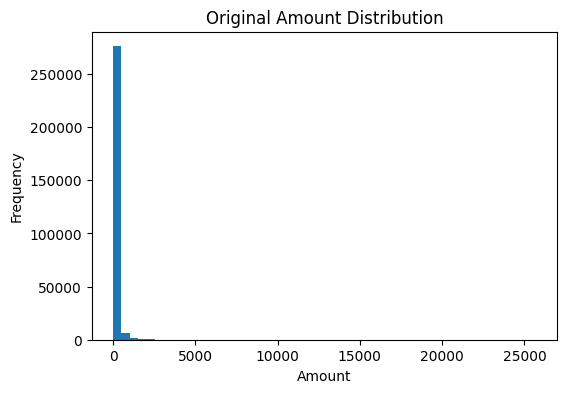

In [4]:
plt.figure(figsize=(6, 4))
plt.hist(df["Amount"], bins=50)
plt.title("Original Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

The original `Amount` feature is heavily right-skewed. Most transactions are relatively small, while a small number of transactions have very large values. This makes the distribution difficult to interpret directly.

### Apply Log Transformation to `Amount`

In [5]:
df["Amount_log"] = np.log1p(df["Amount"])
df[["Amount", "Amount_log"]].head()

,Amount,Amount_log
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


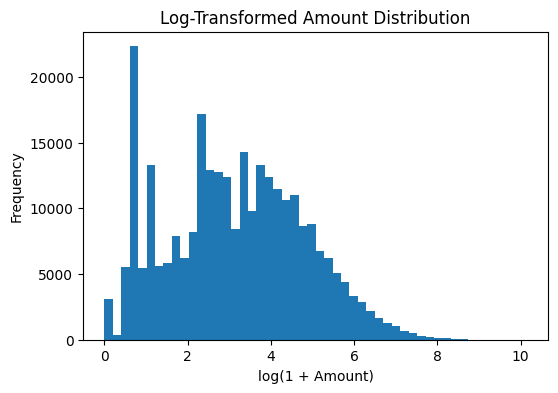

In [6]:
plt.figure(figsize=(6, 4))
plt.hist(df["Amount_log"], bins=50)
plt.title("Log-Transformed Amount Distribution")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Frequency")
plt.show()

The log transformation reduces the effect of extremely large transaction values and spreads the distribution more evenly. This makes the `Amount` feature easier to visualize and potentially more suitable for some modeling approaches.

### Compare Original and Transformed Features

In [7]:
print("Original Amount summary:")
print(df["Amount"].describe())

print("\nLog-Transformed Amount summary:")
print(df["Amount_log"].describe())

Original Amount summary:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Log-Transformed Amount summary:
count    284807.000000
mean          3.152188
std           1.656648
min           0.000000
25%           1.887070
50%           3.135494
75%           4.358822
max          10.153941
Name: Amount_log, dtype: float64


### Save Engineered Dataset

In [8]:
output_path = "../data/processed/creditcard_engineered.csv"
df.to_csv(output_path, index=False)
print(f"Engineered dataset saved to: {output_path}")

Engineered dataset saved to: ../data/processed/creditcard_engineered.csv


### Interpretation

Only limited feature engineering was applied in this project because the dataset was already highly processed. The main transformation introduced was a log-transformed version of the `Amount` feature, which addressed the strong skew in the original transaction amounts.

This transformation improves interpretability and may also be useful in future model development or experimentation. The engineered dataset was saved to the `data/processed` folder for possible reuse in later analysis.